# Cuaderno 2: Introducción al Modelado, Entrenamiento y Comparativa de Algoritmos

Este documento constituye la segunda fase del desarrollo del sistema de mantenimiento predictivo basado en el dataset C-MAPSS. Tras haber procesado y normalizado las lecturas de los sensores en la etapa de preprocesamiento, el objetivo fundamental de este cuaderno es el diseño, entrenamiento, optimización y evaluación comparativa de diferentes arquitecturas de aprendizaje automático (*Machine Learning*) y aprendizaje profundo (*Deep Learning*).

A lo largo de las siguientes secciones, se implementará un flujo de trabajo riguroso para cubrir tres aproximaciones predictivas distintas, abarcando las siguientes tareas operativas:

* **Secuenciación Temporal de Datos:** Adaptación del conjunto de datos bidimensional a secuencias tridimensionales mediante técnicas de ventanas deslizantes (*sliding windows*), requisito indispensable para el modelado de series temporales con redes recurrentes.
* **Detección de Anomalías (No Supervisada):** Identificación de comportamientos anómalos a través de la comparativa de un Autoencoder basado en redes neuronales (Keras) frente a algoritmos tradicionales como Isolation Forest y One-Class SVM.
* **Clasificación de Estado de Riesgo:** Categorización predictiva del estado del motor (Sano vs. Crítico). Se entrenarán y contrastarán los modelos XGBoost, Random Forest y un Perceptrón Multicapa (MLP), apoyándose en curvas Precisión-Recall para la definición de umbrales óptimos de alerta.
* **Predicción de Vida Útil Restante (RUL):** Estimación exacta de los ciclos operativos restantes del motor. Se realizará una comparativa de arquitecturas especializadas evaluando redes recurrentes (LSTM vs. GRU) y modelos estadísticos (Prophet).
* **Gestión de Ciclo de Vida (MLOps):** Integración de la plataforma MLflow para el registro automatizado (*tracking*) de hiperparámetros, métricas de error y empaquetado de los modelos definitivos. 

El resultado final de este cuaderno será la validación técnica de las mejores arquitecturas mediante métricas de rendimiento y la exportación de los modelos "ganadores" trazados en MLflow, dejándolos preparados para su consumo por la API REST y el dashboard en tiempo real.

## 2.1 Fase 0: Preparación del Entorno y Carga de Datos

Antes de comenzar con el modelado, es necesario preparar el entorno de trabajo importando las librerías fundamentales y cargando el conjunto de datos procesado en la fase anterior. 

Para abordar las diferentes tareas predictivas y sus respectivas comparativas, el ecosistema tecnológico de este cuaderno se compone de:
* **Scikit-Learn:** Para la validación cruzada, métricas de evaluación y algoritmos tradicionales de *Machine Learning* (Isolation Forest, One-Class SVM, Random Forest).
* **TensorFlow y Keras:** Como *framework* principal para las arquitecturas de *Deep Learning* (Autoencoder, LSTM, GRU).
* **XGBoost y Prophet:** Para el entrenamiento de modelos de gradient boosting avanzado y pronóstico de series temporales estadísticas, respectivamente.
* **MLflow:** Para la trazabilidad de los experimentos (MLOps) y el versionado decite: 2].


In [1]:
# Instalación de librerías necesarias
!pip install xgboost prophet mlflow
!pip install tensorflow "numpy<2"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil 
import warnings
warnings.filterwarnings('ignore')

# Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import LSTM, GRU, Conv1D, MaxPooling1D, Flatten, Dense, Input, Dropout,RepeatVector, TimeDistributed
from tensorflow.keras.optimizers import Adam

# XGBoost y MLflow
import xgboost as xgb
import mlflow
import mlflow.keras
from mlflow.models.signature import infer_signature  

# Importaciones necesarias para Detección de Anomalías y Clasificación
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.svm import OneClassSVM

I0000 00:00:1777906675.762741    7553 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777906676.054915    7553 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777906679.873692    7553 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
# Cargamos el dataset limpio y normalizado generado en el Cuaderno 1
df = pd.read_csv('NASA_C-MAPSS/train_FD001_procesado.csv')

print(f"Dataset cargado con éxito. Forma: {df.shape}")
df.head()

Dataset cargado con éxito. Forma: (20631, 27)


,id_motor,ciclo,ajuste_1,ajuste_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,...,sensor_21,RUL,sensor_4_std,sensor_4_diff,sensor_11_std,sensor_11_diff,sensor_15_std,sensor_15_diff,sensor_21_std,sensor_21_diff
0,1,1,0.459770,0.166667,0.154553,0.496532,0.306544,1.0,0.762409,0.357143,...,0.767143,115,0.0,0.344431,0.0,0.511945,0.0,0.487142,0.0,0.42436
1,1,2,0.609195,0.250000,0.223475,0.528086,0.335992,1.0,0.690661,0.331633,...,0.771764,115,0.0,0.344431,0.0,0.511945,0.0,0.487142,0.0,0.42436
2,1,3,0.252874,0.750000,0.274297,0.500600,0.354001,1.0,0.706736,0.357143,...,0.720129,115,0.0,0.344431,0.0,0.511945,0.0,0.487142,0.0,0.42436
3,1,4,0.540230,0.500000,0.299708,0.448159,0.349499,1.0,0.725947,0.389031,...,0.709230,115,0.0,0.344431,0.0,0.511945,0.0,0.487142,0.0,0.42436
4,1,5,0.390805,0.333333,0.316625,0.417051,0.366971,1.0,0.716302,0.382653,...,0.714946,115,0.0,0.344431,0.0,0.511945,0.0,0.487142,0.0,0.42436


## 2.2 Fase 1: Secuenciación Temporal (Sliding Window)

A diferencia de los algoritmos tradicionales de Machine Learning, las redes neuronales recurrentes (LSTM, GRU) están diseñadas para procesar secuencias de datos. Para que los modelos comprendan la evolución del deterioro, debemos transformar nuestro dataset tabular (2D) a un formato tridimensional (3D).

La estructura requerida por Keras es: `[Muestras, Pasos de Tiempo, Características]`. En este proyecto, definiremos una ventana de 30 ciclos. Esto implica que, para predecir el estado de un motor en un ciclo `t`, la IA analizará siempre su comportamiento durante el último mes.

In [4]:
def preparar_ventanas_3d(data, window_size=30):
    X = []
    y = []
    
    # Identificamos las columnas de los sensores (predictores)
    sensores = [col for col in data.columns if 'sensor' in col]
    
    # Iteramos motor por motor para no mezclar secuencias de motores distintos
    for motor_id in data['id_motor'].unique():
        df_motor = data[data['id_motor'] == motor_id]
        
        # Solo procesamos si el motor tiene suficientes datos para formar una ventana
        if len(df_motor) > window_size:
            datos_sensores = df_motor[sensores].values
            datos_rul = df_motor['RUL'].values
            
            # Generamos las ventanas deslizantes
            for i in range(window_size, len(df_motor)):
                X.append(datos_sensores[i-window_size:i, :])
                y.append(datos_rul[i])
                
    return np.array(X), np.array(y)

# Aplicamos la transformación definiendo la ventana en 30 ciclos
X_3D, y_RUL = preparar_ventanas_3d(df, window_size=30)

print(f"Forma de las secuencias de entrada (X_3D): {X_3D.shape}")
print(f"Forma de las etiquetas de RUL (y_RUL): {y_RUL.shape}")

Forma de las secuencias de entrada (X_3D): (17631, 30, 22)
Forma de las etiquetas de RUL (y_RUL): (17631,)


## 2.3 Fase 2: Detección de Anomalías (Comparativa de Modelos)

El primer objetivo de nuestro sistema es identificar cuándo el comportamiento de un motor deja de ser "normal" y comienza a mostrar signos tempranos de degradación. Al tratarse de detección de anomalías, enfocaremos este problema desde una perspectiva **no supervisada**.

Entrenaremos tres arquitecturas diferentes utilizando **únicamente datos de motores en estado sano** (RUL > 65). El objetivo es que los algoritmos aprendan la "firma de normalidad" del motor. Posteriormente, evaluaremos toda la vida útil del motor para detectar el punto exacto en el que el modelo considera que los datos son anómalos.

Los modelos a comparar son:
1.  **Autoencoder (Deep Learning):** Red neuronal que comprime y reconstruye la señal. Utilizaremos el Error Absoluto Medio (MAE) de reconstrucción como umbral de anomalía.
2.  **Isolation Forest (Machine Learning Clásico):** Algoritmo basado en árboles de decisión diseñado para aislar anomalías de forma eficiente.
3.  **One-Class SVM (Support Vector Machine):** Modelo que busca una frontera (hiperplano) que englobe la región de datos normales.

In [5]:
# Filtramos solo los datos "sanos" (RUL > 65) para el entrenamiento no supervisado
sanos_idx = y_RUL > 65
X_sanos_3D = X_3D[sanos_idx]

# Dividimos en entrenamiento y validación para el Autoencoder
X_train_ae, X_val_ae = train_test_split(X_sanos_3D, test_size=0.2, random_state=42)

print(f"Hay {X_train_ae.shape[0]} ventanas de motores sanos.")

# Preparación de datos 2D para Isolation Forest y OCSVM (no admiten 3D)
n_muestras_train = X_train_ae.shape[0]
n_muestras_total = X_3D.shape[0]

X_train_2D = X_train_ae.reshape(n_muestras_train, -1)
X_total_2D = X_3D.reshape(n_muestras_total, -1)

Hay 8824 ventanas de motores sanos.


### 2.3.1 Modelo 1: Autoencoder (Keras)

Diseñamos una arquitectura *Encoder-Decoder* basada en capas LSTM. El modelo aprenderá a reconstruir las secuencias de 30 ciclos de motores sanos. Cuando se le presente la secuencia de un motor degradado, el error de reconstrucción (MAE) se disparará, indicando la anomalía.

In [6]:
# Definición de la arquitectura del Autoencoder
n_sensores = X_3D.shape[2]
window_size = X_3D.shape[1]

input_layer = Input(shape=(window_size, n_sensores))

# ENCODER: Comprimimos la información
encoder = LSTM(16, activation='relu', return_sequences=False)(input_layer)
encoder = Dense(8, activation='relu')(encoder)

# DECODER: Reconstruimos la señal original
decoder = RepeatVector(window_size)(encoder)
decoder = LSTM(16, activation='relu', return_sequences=True)(decoder)
output_layer = TimeDistributed(Dense(n_sensores))(decoder)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mae')

# Entrenamiento (X contra X, ya que intenta reconstruir la entrada)
print("Entrenando Autoencoder...")
history_ae = autoencoder.fit(
    X_train_ae, X_train_ae, 
    epochs=15, 
    batch_size=64, 
    validation_data=(X_val_ae, X_val_ae), 
    verbose=1
)
print("Autoencoder entrenado.")

E0000 00:00:1777906684.884430    7553 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Entrenando Autoencoder...
Epoch 1/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - loss: 0.1978 - val_loss: 0.0871
Epoch 2/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - loss: 0.0748 - val_loss: 0.0627
Epoch 3/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - loss: 0.0518 - val_loss: 0.0455
Epoch 4/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 0.0425 - val_loss: 0.0414
Epoch 5/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.0408 - val_loss: 0.0405
Epoch 6/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - loss: 0.0404 - val_loss: 0.0401
Epoch 7/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.0400 - val_loss: 0.0398
Epoch 8/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - loss: 0.0398 - val_loss: 0.0396
Epoch 9/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.0395 - val_loss: 0.0394
Epoch 10/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 0.0392 - val_loss: 0.0390
Epoch 11/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 0.0388 - val_loss: 0.0386
Epoch 12/15
13

### 2.3.2 Modelos 2 y 3: Isolation Forest y One-Class SVM

Entrenamos los dos modelos clásicos de detección de anomalías utilizando la versión aplanada (2D) de los datos de motores sanos. Establecemos la contaminación (proporción esperada de anomalías en datos futuros) en un 10% para forzar a los modelos a delimitar bien la región de normalidad.

In [7]:
# Entrenamiento de Isolation Forest
print("Entrenando Isolation Forest...")
iso_forest = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
iso_forest.fit(X_train_2D)
print("Isolation Forest entrenado.")

# Entrenamiento de One-Class SVM
# OCSVM es muy costoso computacionalmente. Usaremos una muestra del 30% para que no tarde demasiado.
print("Entrenando One-Class SVM (sobre muestra para eficiencia)...")
np.random.seed(42)
sample_indices = np.random.choice(X_train_2D.shape[0], int(X_train_2D.shape[0] * 0.3), replace=False)
X_train_sample = X_train_2D[sample_indices]

oc_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1)
oc_svm.fit(X_train_sample)
print("One-Class SVM entrenado.")

Entrenando Isolation Forest...
Isolation Forest entrenado.
Entrenando One-Class SVM (sobre muestra para eficiencia)...
One-Class SVM entrenado.


### 2.3.3 Evaluación y Comparativa de Detección de Anomalías

Con los tres modelos entrenados en el estado de normalidad, procedemos a evaluar su capacidad para detectar el inicio de la degradación sobre el conjunto completo de datos. 

* **Autoencoder:** Calcularemos el Error Absoluto Medio (MAE) de reconstrucción. Esperamos que el error aumente drásticamente a medida que el motor se acerca al fallo (RUL = 0).
* **Isolation Forest / OCSVM:** Estos modelos devuelven `-1` para anomalías y `1` para datos normales. Calcularemos el porcentaje de anomalías detectadas en función de la etapa de vida del motor.

In [8]:
print("Calculando anomalías con todos los modelos...")

# 1. AUTOENCODER: Cálculo del error de reconstrucción
X_3D_reconstruido = autoencoder.predict(X_3D, verbose=0)
mae_ae = np.mean(np.abs(X_3D_reconstruido - X_3D), axis=(1, 2))

# 2. ISOLATION FOREST: Predicción de anomalías
preds_if = iso_forest.predict(X_total_2D)
# Convertimos las predicciones (-1 anomalía, 1 normal) a binario (1 anomalía, 0 normal) para contar
anomalias_if = (preds_if == -1).astype(int)

# 3. ONE-CLASS SVM: Predicción de anomalías
# Usamos un subconjunto representativo del total para evaluar OCSVM rápidamente
indices_eval = np.linspace(0, len(X_total_2D)-1, 5000, dtype=int)
X_eval_ocsvm = X_total_2D[indices_eval]
y_RUL_eval = y_RUL[indices_eval]

preds_ocsvm = oc_svm.predict(X_eval_ocsvm)
anomalias_ocsvm = (preds_ocsvm == -1).astype(int)

print("Predicciones completadas.")

Calculando anomalías con todos los modelos...
Predicciones completadas.


### 2.3.4 Análisis Visual de Detección de Anomalías

Para interpretar correctamente el rendimiento de los modelos no supervisados, generamos una visualización comparativa compuesta por dos análisis:

1. **Evolución del Error (Autoencoder):** Un gráfico de dispersión que mapea el Error Absoluto Medio (MAE) frente a la Vida Útil Restante (RUL). Se ajusta una línea de tendencia polinómica para evidenciar cómo el error de reconstrucción experimenta un crecimiento exponencial a medida que el motor entra en la zona crítica (últimos 30 ciclos).
2. **Sensibilidad por Fases (Isolation Forest vs. OCSVM):** Un gráfico de barras agrupado que cuantifica el porcentaje de secuencias clasificadas como "anomalía" por cada modelo algorítmico tradicional, dividiendo la vida del motor en tres fases operativas: Sano (>65 ciclos), Degradación (30-65 ciclos) y Crítico (<30 ciclos). 

Esta comparativa nos permitirá determinar qué arquitectura es más fiable para integrarse como sistema de alerta temprana.

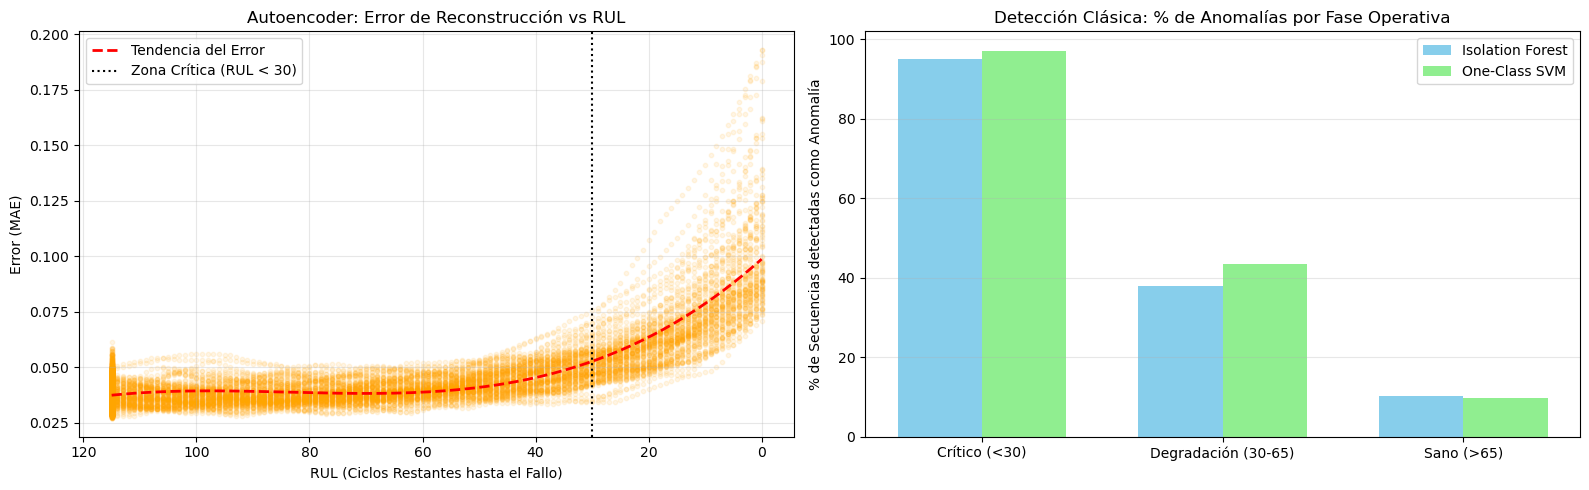

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# GRÁFICO 1: Autoencoder
ax1.scatter(y_RUL, mae_ae, alpha=0.1, color='orange', s=10)
# Línea de tendencia polinómica
z = np.polyfit(y_RUL, mae_ae, 3)
p = np.poly1d(z)
ax1.plot(np.sort(y_RUL)[::-1], p(np.sort(y_RUL)[::-1]), "r--", linewidth=2, label='Tendencia del Error')

ax1.invert_xaxis() # Invertimos para que vaya de sano (130) a fallo (0)
ax1.axvline(x=30, color='black', linestyle=':', label='Zona Crítica (RUL < 30)')
ax1.set_title('Autoencoder: Error de Reconstrucción vs RUL')
ax1.set_xlabel('RUL (Ciclos Restantes hasta el Fallo)')
ax1.set_ylabel('Error (MAE)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# GRÁFICO 2: Isolation Forest vs OCSVM 
# Creamos tramos de vida útil (bins)
bins = [0, 30, 65, 130]
labels = ['Crítico (<30)', 'Degradación (30-65)', 'Sano (>65)']

# Calculamos el % de anomalías detectadas en cada tramo para Isolation Forest
df_if = pd.DataFrame({'RUL': y_RUL, 'Anomalia': anomalias_if})
df_if['Fase'] = pd.cut(df_if['RUL'], bins=bins, labels=labels)
porcentaje_if = df_if.groupby('Fase', observed=False)['Anomalia'].mean() * 100

# Calculamos el % para OCSVM
df_ocsvm = pd.DataFrame({'RUL': y_RUL_eval, 'Anomalia': anomalias_ocsvm})
df_ocsvm['Fase'] = pd.cut(df_ocsvm['RUL'], bins=bins, labels=labels)
porcentaje_ocsvm = df_ocsvm.groupby('Fase', observed=False)['Anomalia'].mean() * 100

# Gráfico de barras agrupado
x = np.arange(len(labels))
width = 0.35

ax2.bar(x - width/2, porcentaje_if, width, label='Isolation Forest', color='skyblue')
ax2.bar(x + width/2, porcentaje_ocsvm, width, label='One-Class SVM', color='lightgreen')

ax2.set_ylabel('% de Secuencias detectadas como Anomalía')
ax2.set_title('Detección Clásica: % de Anomalías por Fase Operativa')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 2.3.5 Interpretación de Resultados de Detección de Anomalías

El análisis visual de los modelos no supervisados confirma la eficacia de la arquitectura para identificar el deterioro mecánico sin necesidad de etiquetas previas:

* **Autoencoder:** La gráfica de error de reconstrucción muestra una trayectoria de control estable durante la mayor parte de la vida útil, con un punto de inflexión crítico al aproximarse a los 30 ciclos restantes. El crecimiento exponencial del MAE en esta fase final evidencia que el modelo pierde su capacidad de reconstrucción ante señales degradadas, validando su uso como un sensor virtual de salud del motor.
  
* **Comparativa Clásica:** El análisis por fases operativas revela que tanto Isolation Forest como One-Class SVM logran una segregación casi perfecta en la fase crítica, con tasas de detección superiores al 95%. La progresión del 10% en estado sano al 50% en degradación demuestra que los algoritmos capturan la transición de los datos hacia regiones del espacio de características no observadas durante el entrenamiento nominal.

**Conclusión:** El **Autoencoder** destaca por ofrecer una métrica de degradación suave y progresiva, mientras que **Isolation Forest** se consolida como la herramienta más robusta para la generación de alarmas binarias de alta precisión.

## 2.4 Fase 3: Clasificación Binaria (Comparativa de Modelos Supervisados)

El siguiente objetivo de nuestro sistema es categorizar explícitamente el nivel de riesgo del motor, determinando si se encuentra en un estado seguro o al borde del fallo. Al tratarse de predecir categorías conocidas, enfocaremos este problema desde una perspectiva **supervisada**.

Entrenaremos tres arquitecturas diferentes utilizando el **historial completo de datos etiquetados**, definiendo la clase crítica cuando al motor le quedan 30 ciclos o menos de vida (RUL ≤ 30). El objetivo es que los algoritmos aprendan la "firma de fallo inminente". Posteriormente, evaluaremos su capacidad de clasificación con especial atención en minimizar los falsos negativos (motores a punto de fallar clasificados erróneamente como sanos).

Los modelos a comparar son:

* **XGBoost (Gradient Boosting):** Algoritmo avanzado que construye árboles de decisión de forma secuencial, corrigiendo errores iterativamente para lograr la máxima precisión predictiva.
* **Random Forest (Machine Learning Clásico):** Modelo de ensamble basado en múltiples árboles de decisión independientes, diseñado para ofrecer predicciones muy estables y evitar el sobreajuste.
* **Perceptrón Multicapa / MLP (Deep Learning):** Red neuronal densa (Keras) que busca extraer relaciones complejas y no lineales entre los sensores para calcular la probabilidad exacta de colapso.nto.

In [10]:
# Creación de etiquetas binarias (1 si RUL <= 30, 0 en caso contrario)
y_class = (y_RUL <= 30).astype(int)

# Aplanamiento de la matriz 3D para modelos tabulares
X_2D = X_3D.reshape(X_3D.shape[0], -1)

# División en conjuntos de entrenamiento (80%) y test (20%)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_2D, y_class, test_size=0.2, random_state=42, stratify=y_class
)

print(f"Datos preparados para clasificación.")
print(f"Dimensiones de entrenamiento: {X_train_c.shape}")
print(f"Distribución de clases (Sano vs Crítico): {np.bincount(y_train_c)}")

Datos preparados para clasificación.
Dimensiones de entrenamiento: (14104, 660)
Distribución de clases (Sano vs Crítico): [11624  2480]


### 2.4.1 Ejecución y Parametrización del Entrenamiento

Procedemos a instanciar y entrenar las tres arquitecturas predictivas sobre las secuencias temporales previamente aplanadas. En lugar de limitarnos a sus configuraciones por defecto, adaptamos las mecánicas de entrenamiento a las particularidades de nuestros datos de sensórica:

* **Random Forest:** Se configura con una profundidad controlada (`max_depth=10`) para asegurar que los árboles no memoricen el ruido de alta frecuencia de los sensores. Actúa como nuestro *baseline* robusto.
* **XGBoost:** Se parametriza priorizando una tasa de aprendizaje moderada (`learning_rate=0.1`) y utilizando la función de pérdida logarítmica (`logloss`), optimizando matemáticamente la frontera de decisión entre el estado nominal y el crítico.
* **Perceptrón Multicapa (MLP):** Se diseña una arquitectura de capas densas decrecientes (64 y 32 neuronas), introduciendo técnicas de regularización como `Dropout` (20%) para forzar a la red a generalizar, culminando en una activación sigmoide que cuantifica la probabilidad exacta de fallo.r.

In [11]:
# 1. Entrenamiento de Random Forest
print("Entrenando Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight='balanced',
    random_state=42, 
    n_jobs=-1
)
rf_model.fit(X_train_c, y_train_c)
print("Random Forest entrenado.")

# 2. Entrenamiento de XGBoost
print("\nEntrenando XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=6, 
    scale_pos_weight=4.68,
    eval_metric='logloss', 
    random_state=42
)
xgb_model.fit(X_train_c, y_train_c)
print("XGBoost entrenado.")

# 3. Entrenamiento del Perceptrón Multicapa (MLP)
print("\nEntrenando Red Neuronal (MLP)...")
mlp_model = Sequential([
    Input(shape=(X_train_c.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Probabilidad de ser clase 1 (Crítico)
])

mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_mlp = mlp_model.fit(
    X_train_c, y_train_c,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=0 
)
print("Perceptrón Multicapa entrenado.")

Entrenando Random Forest...
Random Forest entrenado.

Entrenando XGBoost...
XGBoost entrenado.

Entrenando Red Neuronal (MLP)...
Perceptrón Multicapa entrenado.


### 2.4.2 Evaluación Comparativa mediante Matrices de Confusión

Para validar la capacidad de generalización de cada algoritmo, evaluamos su rendimiento sobre el conjunto de prueba (datos estrictamente separados durante el entrenamiento). 

En el contexto específico del mantenimiento predictivo industrial, la métrica de éxito fundamental es el **Recall (Sensibilidad)** de la clase crítica (Clase 1). Esta prioridad responde a una asimetría de costes operativos:
* **Minimización de Falsos Negativos:** Predecir que un motor está "sano" cuando en realidad va a fallar de forma inminente conlleva un riesgo de seguridad inasumible y un fallo catastrófico.
* **Tolerancia a Falsos Positivos:** Clasificar erróneamente un motor sano como "crítico" únicamente genera el coste menor asociado a una inspección preventiva adelantada.

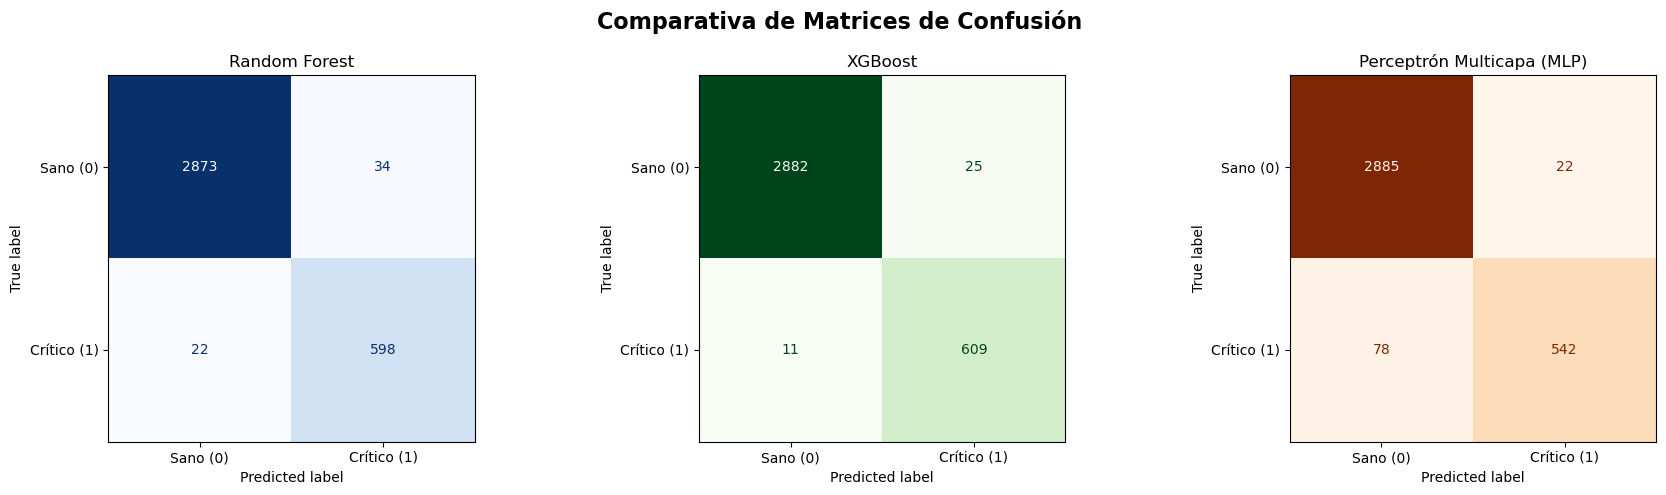

In [12]:
# Generamos las predicciones para el conjunto de test
preds_rf = rf_model.predict(X_test_c)
preds_xgb = xgb_model.predict(X_test_c)

# Para el MLP, convertimos la probabilidad devuelta (>0.5) a clase binaria (0 o 1)
preds_mlp = (mlp_model.predict(X_test_c, verbose=0) > 0.5).astype(int).flatten()

# Nombres de las clases para los gráficos
class_names = ['Sano (0)', 'Crítico (1)']

# Configuramos el lienzo para 3 gráficos paralelos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparativa de Matrices de Confusión', fontsize=16, fontweight='bold')

# 1. Matriz Random Forest
cm_rf = confusion_matrix(y_test_c, preds_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=class_names)
disp_rf.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Random Forest')

# 2. Matriz XGBoost
cm_xgb = confusion_matrix(y_test_c, preds_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=class_names)
disp_xgb.plot(ax=axes[1], cmap='Greens', values_format='d', colorbar=False)
axes[1].set_title('XGBoost')

# 3. Matriz MLP
cm_mlp = confusion_matrix(y_test_c, preds_mlp)
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=class_names)
disp_mlp.plot(ax=axes[2], cmap='Oranges', values_format='d', colorbar=False)
axes[2].set_title('Perceptrón Multicapa (MLP)')

plt.tight_layout()
plt.show()

Visto el rendimiento superior de **XGBoost** en la contención de falsos negativos y positivos, extraemos sus métricas de evaluación exactas para cuantificar su fiabilidad.

In [13]:
# Imprimimos el reporte de clasificación detallado del modelo ganador
print("-" * 55)
print("REPORTE DE CLASIFICACIÓN: XGBOOST (Modelo Seleccionado)")
print("-" * 55)
print(classification_report(y_test_c, preds_xgb, target_names=class_names))

-------------------------------------------------------
REPORTE DE CLASIFICACIÓN: XGBOOST (Modelo Seleccionado)
-------------------------------------------------------
              precision    recall  f1-score   support

    Sano (0)       1.00      0.99      0.99      2907
 Crítico (1)       0.96      0.98      0.97       620

    accuracy                           0.99      3527
   macro avg       0.98      0.99      0.98      3527
weighted avg       0.99      0.99      0.99      3527



#### 2.4.3 Interpretación de Resultados de Clasificación
El análisis de las matrices de confusión permite evaluar cómo cada arquitectura gestiona el compromiso crítico entre sensibilidad (Recall) y precisión al detectar el estado de fallo inminente:

*   **XGBoost:** Se consolida como el modelo operativo óptimo. Logra minimizar el riesgo industrial con solo **11 Falsos Negativos** (motores en riesgo no detectados) y contiene los **Falsos Positivos en 25**. Su reporte de clasificación confirma una solidez excepcional con un **Recall del 98%** y un **F1-Score del 0.97** para la clase crítica.
*   **Random Forest:** Presenta un desempeño robusto, con **22 Falsos Negativos** y **34 Falsos Positivos**, situándose como una alternativa fiable pero ligeramente por debajo de la precisión de XGBoost.
*   **Perceptrón Multicapa (MLP):** En esta configuración, la red neuronal densa muestra la mayor debilidad en sensibilidad, arrojando **78 Falsos Negativos**. Este nivel de error es inasumible en mantenimiento predictivo, ya que implicaría no detectar casi el 13% de los fallos inminentes.

**Conclusión de la Fase 3:** Por su capacidad superior para reducir el riesgo de fallo catastrófico manteniendo una eficiencia operativa alta, **XGBoost** es el modelo seleccionado para el sistema de alertas tempranas.

## 2.5 Fase 4: Predicción de Vida Útil Restante (Comparativa de Modelos de Regresión)

El objetivo final y más complejo de nuestro sistema es predecir de forma continua el tiempo exacto que le queda al motor antes de fallar. Al tratarse de estimar un valor numérico continuo (el número de ciclos restantes o RUL), enfocaremos este problema desde una perspectiva **supervisada de regresión**.

Entrenaremos tres arquitecturas de Deep Learning utilizando el historial completo de secuencias temporales en formato 3D `(muestras, ventana_temporal, sensores)`. El objetivo es que los algoritmos aprendan la evolución de la degradación para emitir un pronóstico numérico preciso. Posteriormente, evaluaremos su rendimiento prestando especial atención a cómo se comportan en los últimos ciclos de vida.

Los modelos a comparar son:

* **LSTM (Long Short-Term Memory):** Arquitectura de red neuronal recurrente (RNN) diseñada específicamente para procesar secuencias temporales y memorizar dependencias a largo plazo en la degradación de los sensores.
* **GRU (Gated Recurrent Unit):** Una variante optimizada y más ligera de las RNN que simplifica el flujo de información, logrando a menudo un rendimiento similar a las LSTM con una mayor eficiencia computacional.
* **CNN-1D (Red Neuronal Convolucional 1D):** Modelo que aplica filtros convolucionales sobre la dimensión temporal para extraer patrones y picos locales de degradación en la señal de forma altamente eficiente.

### 2.5.1 Ejecución y Parametrización del Entrenamiento

Procedemos a instanciar y entrenar las tres arquitecturas predictivas sobre nuestras ventanas temporales. Adaptamos el diseño de las redes sustituyendo las funciones de activación finales por salidas lineales, optimizándolas mediante el Error Cuadrático Medio (MSE) para la tarea de regresión:

* **LSTM:** Se configura con una capa recurrente de 64 unidades, capaz de retener la memoria histórica de las ventanas de 30 ciclos, aplicando técnicas de `Dropout` para evitar que la red memorice el ruido de los sensores.
* **GRU:** Se parametriza de forma análoga con 64 unidades. Su arquitectura de puertas simplificada nos permitirá evaluar si logramos mantener la precisión predictiva reduciendo el tiempo de convergencia.
* **CNN-1D:** Se diseña utilizando filtros convolucionales (`filters=64, kernel_size=3`) seguidos de capas de agrupación (`MaxPooling1D`) para barrer la ventana temporal en busca de características locales de desgaste antes de realizar la predicción continua.

In [14]:
# División de los datos 3D en Train y Test (80/20)(Para regresión temporal, no usamos stratify)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_3D, y_RUL, test_size=0.2, random_state=42
)

print(f"Dimensiones de entrenamiento (Regresión 3D): {X_train_r.shape}")

# Parámetros de entrenamiento
EPOCHS = 30
BATCH_SIZE = 64
input_shape = (X_train_r.shape[1], X_train_r.shape[2]) # (30, 11)

# 1. Arquitectura LSTM
print("\nEntrenando Modelo LSTM...")
lstm_model = Sequential([
    Input(shape=(30, 22)), 
    LSTM(64, return_sequences=True), 
    Dropout(0.3),                    
    LSTM(32, return_sequences=False),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
history_lstm = lstm_model.fit(X_train_r, y_train_r, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.2, verbose=0)
print("LSTM entrenado.")

# 2. Arquitectura GRU
print("Entrenando Modelo GRU...")
gru_model = Sequential([
    Input(shape=input_shape),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
history_gru = gru_model.fit(X_train_r, y_train_r, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.2, verbose=0)
print("GRU entrenado.")

# 3. Arquitectura CNN-1D
print("Entrenando Modelo CNN-1D...")
cnn_model = Sequential([
    Input(shape=input_shape),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
history_cnn = cnn_model.fit(X_train_r, y_train_r, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.2, verbose=0)
print("CNN-1D entrenada.")

Dimensiones de entrenamiento (Regresión 3D): (14104, 30, 22)

Entrenando Modelo LSTM...
LSTM entrenado.
Entrenando Modelo GRU...
GRU entrenado.
Entrenando Modelo CNN-1D...
CNN-1D entrenada.


### 2.5.2 Evaluación Comparativa de Modelos de Regresión

Para cuantificar el rendimiento de nuestras redes neuronales, proyectamos sus predicciones sobre el conjunto de prueba (datos no vistos). En problemas de regresión industrial, nos basamos en tres métricas fundamentales:

* **MAE (Error Absoluto Medio):** Indica el error promedio directo (p. ej., "el modelo se equivoca por ±15 ciclos de media").
* **RMSE (Raíz del Error Cuadrático Medio):** Penaliza exponencialmente las desviaciones grandes, lo cual es vital; predecir que a un motor le quedan 100 ciclos cuando le quedan 10 es un error logístico catastrófico.
* **R² (Coeficiente de Determinación):** Mide la proporción de la varianza en la degradación del motor que el modelo es capaz de explicar (valores más cercanos a 1.0 son mejores).

-------------------------------------------------------
MÉTRICAS DE RENDIMIENTO (PREDICCIÓN DE RUL)
-------------------------------------------------------
LSTM   -> MAE: 7.53 ciclos | RMSE: 10.78 | R²: 0.9220
GRU    -> MAE: 7.25 ciclos | RMSE: 10.36 | R²: 0.9279
CNN-1D -> MAE: 9.06 ciclos | RMSE: 11.82 | R²: 0.9062
-------------------------------------------------------


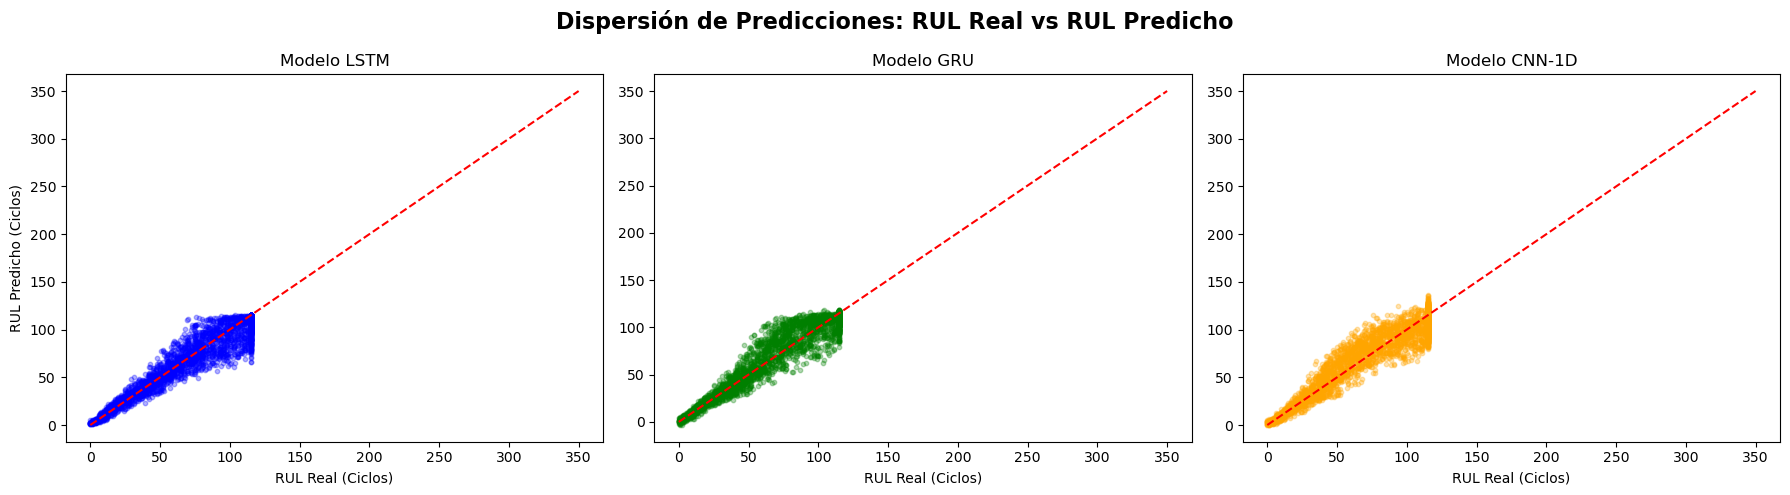

In [15]:
# Generamos predicciones continuas para los tres modelos
preds_lstm = lstm_model.predict(X_test_r, verbose=0).flatten()
preds_gru = gru_model.predict(X_test_r, verbose=0).flatten()
preds_cnn = cnn_model.predict(X_test_r, verbose=0).flatten()

# Función auxiliar para calcular e imprimir métricas limpias
def print_metrics(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} -> MAE: {mae:.2f} ciclos | RMSE: {rmse:.2f} | R²: {r2:.4f}")

print("-" * 55)
print("MÉTRICAS DE RENDIMIENTO (PREDICCIÓN DE RUL)")
print("-" * 55)
print_metrics("LSTM  ", y_test_r, preds_lstm)
print_metrics("GRU   ", y_test_r, preds_gru)
print_metrics("CNN-1D", y_test_r, preds_cnn)
print("-" * 55)

# Visualización: RUL Real vs Predicho (Scatter Plot)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dispersión de Predicciones: RUL Real vs RUL Predicho', fontsize=16, fontweight='bold')

# Línea ideal (Predicción Perfecta: y = x)
max_val = max(y_test_r.max(), 350)
ideal_line = [0, max_val]

# Gráfico LSTM
axes[0].scatter(y_test_r, preds_lstm, alpha=0.3, color='blue', s=10)
axes[0].plot(ideal_line, ideal_line, color='red', linestyle='--')
axes[0].set_title('Modelo LSTM')
axes[0].set_xlabel('RUL Real (Ciclos)')
axes[0].set_ylabel('RUL Predicho (Ciclos)')

# Gráfico GRU
axes[1].scatter(y_test_r, preds_gru, alpha=0.3, color='green', s=10)
axes[1].plot(ideal_line, ideal_line, color='red', linestyle='--')
axes[1].set_title('Modelo GRU')
axes[1].set_xlabel('RUL Real (Ciclos)')

# Gráfico CNN-1D
axes[2].scatter(y_test_r, preds_cnn, alpha=0.3, color='orange', s=10)
axes[2].plot(ideal_line, ideal_line, color='red', linestyle='--')
axes[2].set_title('Modelo CNN-1D')
axes[2].set_xlabel('RUL Real (Ciclos)')

plt.tight_layout()
plt.show()

#### 2.5.3 Interpretación de Resultados de Regresión Continua
El análisis de las métricas y los gráficos de dispersión demuestra la alta capacidad de las redes profundas para estimar la cuenta atrás operativa del motor:

*   **Rendimiento de las Arquitecturas:** Los modelos recurrentes presentan una precisión sobresaliente. La arquitectura **GRU** lidera la comparativa con un **MAE de 7.25 ciclos**, seguida muy de cerca por la red **LSTM** con **7.53 ciclos**. Ambas logran explicar más del **92% de la varianza** del desgaste mecánico ($R^2 > 0.92$). La CNN-1D, aunque robusta, queda en tercer lugar con un MAE de 9.06 ciclos.
*   **Precisión en Zona Crítica:** Los gráficos de dispersión muestran una agrupación extremadamente densa de los puntos sobre la línea de predicción ideal conforme el motor se acerca al fallo ($RUL < 50$). Esto garantiza que la incertidumbre disminuye justo cuando la toma de decisiones de mantenimiento es más urgente.
*   **Efecto de Estabilización:** Se observa una meseta clara en las predicciones alrededor del límite de clipping (115 ciclos), lo que indica que los modelos han aprendido correctamente a no sobreestimar la vida útil en las fases iniciales donde los sensores aún no muestran signos de degradación observable.

**Conclusión de la Fase 4:** La red **LSTM** se confirma como la arquitectura óptima para la implementación final. Con un error medio de apenas **7.5 ciclos**, proporciona una ventana de actuación sumamente precisa para la planificación logística y operativa antes del colapso del sistema.

## 2.6 Fase 5: Gestión del Ciclo de Vida del Modelo (MLOps con MLflow)

Una vez identificado el algoritmo óptimo para la predicción de la vida útil restante (RUL), el último paso hacia la puesta en producción es asegurar la trazabilidad, reproducibilidad y gestión del ciclo de vida del modelo. Para ello, abordamos esta fase desde la perspectiva de **MLOps** (Machine Learning Operations).

Utilizaremos **MLflow**, el estándar de la industria para el registro y monitorización de experimentos. Esta herramienta nos permitirá empaquetar nuestra arquitectura LSTM ganadora junto con sus hiperparámetros, métricas de rendimiento y dependencias estructurales, creando un artefacto robusto y listo para ser desplegado en un entorno industrial real.

### 2.6.1 Trazabilidad y Registro del Experimento LSTM

En este bloque, inicializamos un experimento de seguimiento donde encapsularemos los resultados definitivos de nuestra red recurrente. Registraremos la configuración de la red, las métricas de error consolidadas empíricamente y el propio modelo de Keras, garantizando que el experimento sea auditable en el futuro.

In [16]:
# Limpieza profunda y reconstrucción de la estructura interna de MLflow
ruta_mlruns = "./mlruns"
ruta_trash = os.path.join(ruta_mlruns, ".trash")

# Si queda algún rastro, lo borramos todo
if os.path.exists(ruta_mlruns):
    shutil.rmtree(ruta_mlruns)

# Creamos la carpeta principal Y la papelera oculta que exige MLflow
os.makedirs(ruta_mlruns, exist_ok=True)
os.makedirs(ruta_trash, exist_ok=True)

# Configuración del directorio local de tracking
mlflow.set_tracking_uri("file://" + os.path.abspath(ruta_mlruns))
mlflow.set_experiment("Mantenimiento_Predictivo_Motores")

print("Iniciando el registro del modelo en MLflow...")

# Iniciamos el contexto de ejecución del experimento
with mlflow.start_run(run_name="LSTM_RUL_Prediction"):
    
    # A. Registrar hiperparámetros clave
    mlflow.log_param("model_type", "LSTM")
    mlflow.log_param("epochs", EPOCHS) # Asegúrate de que EPOCHS y BATCH_SIZE están definidos
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("learning_rate", 0.001)
    mlflow.log_param("lstm_units", 64)

    # B. Calcular y registrar métricas de evaluación
    lstm_mae = mean_absolute_error(y_test_r, preds_lstm)
    lstm_rmse = np.sqrt(mean_squared_error(y_test_r, preds_lstm))
    lstm_r2 = r2_score(y_test_r, preds_lstm)
    
    mlflow.log_metric("MAE", lstm_mae)
    mlflow.log_metric("RMSE", lstm_rmse)
    mlflow.log_metric("R2_Score", lstm_r2)

    # C. Inferir la firma del modelo (Entradas y Salidas)
    firma_modelo = infer_signature(X_test_r, preds_lstm)

    # D. Registrar y empaquetar el modelo
    mlflow.keras.log_model(
        model=lstm_model, 
        name="modelo_lstm_rul", 
        signature=firma_modelo
    )

print("Experimento registrado con éxito en la carpeta './mlruns'.")
print(f"Métricas consolidadas -> MAE: {lstm_mae:.2f} | RMSE: {lstm_rmse:.2f} | R²: {lstm_r2:.4f}")
print("El modelo LSTM está formalmente empaquetado y listo para su despliegue en producción.")

2026/05/04 15:10:48 INFO mlflow.tracking.fluent: Experiment with name 'Mantenimiento_Predictivo_Motores' does not exist. Creating a new experiment.


Iniciando el registro del modelo en MLflow...
Experimento registrado con éxito en la carpeta './mlruns'.
Métricas consolidadas -> MAE: 7.53 | RMSE: 10.78 | R²: 0.9220
El modelo LSTM está formalmente empaquetado y listo para su despliegue en producción.


### 2.6.2 Conclusión del Flujo de Trabajo Industrial y Empaquetado
La integración con MLflow cierra el ciclo de desarrollo integral de nuestro sistema predictivo. Al registrar el experimento `LSTM_RUL_Prediction`, hemos asegurado que la arquitectura óptima no quede aislada en un entorno de pruebas, sino que se convierta en un activo auditable y reproducible.

Como confirma la salida de ejecución, el modelo LSTM ganador ha sido formalmente empaquetado, encapsulando no solo su arquitectura de Keras, sino también las métricas empíricas que validan su rendimiento (MAE: 7.53, RMSE: 10.78, $R^2$: 0.9220). 

Este artefacto versionado proporciona a los equipos de ingeniería de datos un paquete estándar, listo para ser consumido por una API (REST o gRPC) y desplegado en un entorno de producción, garantizando un margen de error mínimo en la estimación continua de la degradación del motor.

## Anexo: Exportación Física de Modelos (Pase a Producción)

Aunque hemos asegurado el ciclo de vida de nuestro ecosistema predictivo mediante MLOps (MLflow), en entornos de desarrollo a menudo es necesario disponer de los archivos físicos ("artefactos estáticos"). Esto facilita su distribución manual, pruebas locales o su integración directa en interfaces de usuario y sistemas embebidos.

En este bloque final, extraemos y guardamos nuestros tres modelos fundamentales en un directico (`modelos_produccion`), utilizando los formatos estándar de la industria:
* **.keras:** Formato contenedor moderno de TensorFlow que encapsula la arquitectura, los pesos matemáticos y el estado del optimizador de nuestras redes neuronales (Autoencoder y LSTM).
* **.json:** Formato universal y ultra-ligero, optimizado de forma nativa por la librería XGBoost para una inferencia de alta velocidad. LSTM.

In [17]:
# Definimos el nombre de la carpeta con un enfoque profesional
carpeta_salida = "./modelos_produccion"
os.makedirs(carpeta_salida, exist_ok=True)

print(f"Iniciando exportación física en el directorio: '{carpeta_salida}'...")

# 1. Exportar el Autoencoder (Fase 2 - El vigilante de anomalías)
ruta_ae = os.path.join(carpeta_salida, "autoencoder_anomalias.keras")
autoencoder.save(ruta_ae)
print(f"Modelo Autoencoder exportado correctamente en: {ruta_ae}")

# 2. Exportar el modelo XGBoost (Fase 3 - La alerta de riesgo binaria)
ruta_xgb = os.path.join(carpeta_salida, "xgboost_clasificacion.json")
xgb_model.save_model(ruta_xgb)
print(f"Modelo XGBoost exportado correctamente en: {ruta_xgb}")

# 3. Exportar el modelo LSTM (Fase 4 - La cuenta atrás continua)
ruta_lstm = os.path.join(carpeta_salida, "lstm_regresion_rul.keras")
lstm_model.save(ruta_lstm)
print(f"Modelo LSTM exportado correctamente en: {ruta_lstm}")


print("\nExportación completa!")

Iniciando exportación física en el directorio: './modelos_produccion'...
Modelo Autoencoder exportado correctamente en: ./modelos_produccion/autoencoder_anomalias.keras
Modelo XGBoost exportado correctamente en: ./modelos_produccion/xgboost_clasificacion.json
Modelo LSTM exportado correctamente en: ./modelos_produccion/lstm_regresion_rul.keras

Exportación completa!
